<a href="https://colab.research.google.com/github/MichaelMaroko/Data-Science-HW1/blob/main/MichaelMaroko/homework2DS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd

# קיבוע seed לשחזור תוצאות מדויק
np.random.seed(42)
n_samples = 1500

# 1. יצירת מאפיינים
regions = ['Tel Aviv', 'Center', 'Sharon', 'Jerusalem', 'North', 'South']
region_probs = [0.22, 0.28, 0.18, 0.12, 0.10, 0.10]
region = np.random.choice(regions, size=n_samples, p=region_probs)

sqm = np.random.normal(95, 30, n_samples).clip(35, 260)
rooms = np.clip(np.round(sqm / 26 + np.random.normal(0, 0.4, n_samples)), 1.5, 6.0)
floor = np.random.randint(0, 18, n_samples)
building_age = np.random.randint(0, 55, n_samples)
has_elevator = (building_age < 20) | (np.random.rand(n_samples) > 0.4)
has_elevator = has_elevator.astype(int)
has_parking = (np.random.rand(n_samples) > 0.35).astype(int)
has_balcony = (np.random.rand(n_samples) > 0.30).astype(int)
dist_to_train_km = np.random.exponential(3.5, n_samples).clip(0.2, 20.0)

# מקדמי מחיר אזוריים (באלפי ש"ח למ"ר)
base_sqm_rate = {
    'Tel Aviv': 44000,
    'Sharon': 31000,
    'Center': 27000,
    'Jerusalem': 26000,
    'South': 15000,
    'North': 14000
}

# 2. חישוב מחיר נכס (מחיר מכירה) כולל רעש והשפעות לא-לינאריות
price_nis = np.zeros(n_samples)
for i in range(n_samples):
    rate = base_sqm_rate[region[i]]
    base_val = sqm[i] * rate
    # תוספות והשפעות
    elevator_val = 80000 * has_elevator[i]
    parking_val = 140000 * has_parking[i]
    balcony_val = 100000 * has_balcony[i]
    age_depreciation = -0.006 * building_age[i] * base_val
    train_premium = max(0, (5 - dist_to_train_km[i])) * 25000

    # רעש והטרוסקדסטיות (בנכסים יקרים השונות בשגיאה גבוהה יותר)
    noise_std = base_val * 0.08
    noise = np.random.normal(0, noise_std)

    price_nis[i] = base_val + elevator_val + parking_val + balcony_val + age_depreciation + train_premium + noise

price_nis = np.maximum(price_nis, 650000).round(-3)

# 3. דמי שכירות ותשואה (מתאים לחלק הסיווג בהמשך)
monthly_rent = (price_nis * np.random.uniform(0.027, 0.038, n_samples) / 12).round(-1)
annual_yield_pct = (monthly_rent * 12) / price_nis * 100
high_yield = (annual_yield_pct >= 3.2).astype(int)

# איחוד ל-DataFrame ושמירה
df = pd.DataFrame({
    'region': region,
    'sqm': sqm.round(1),
    'rooms': rooms,
    'floor': floor,
    'building_age': building_age,
    'has_elevator': has_elevator,
    'has_parking': has_parking,
    'has_balcony': has_balcony,
    'dist_to_train_km': dist_to_train_km.round(2),
    'monthly_rent': monthly_rent,
    'price_nis': price_nis,
    'high_yield': high_yield
})

df.to_csv('israel_real_estate.csv', index=False)
print("Dataset created successfully! Shape:", df.shape)

Dataset created successfully! Shape: (1500, 12)


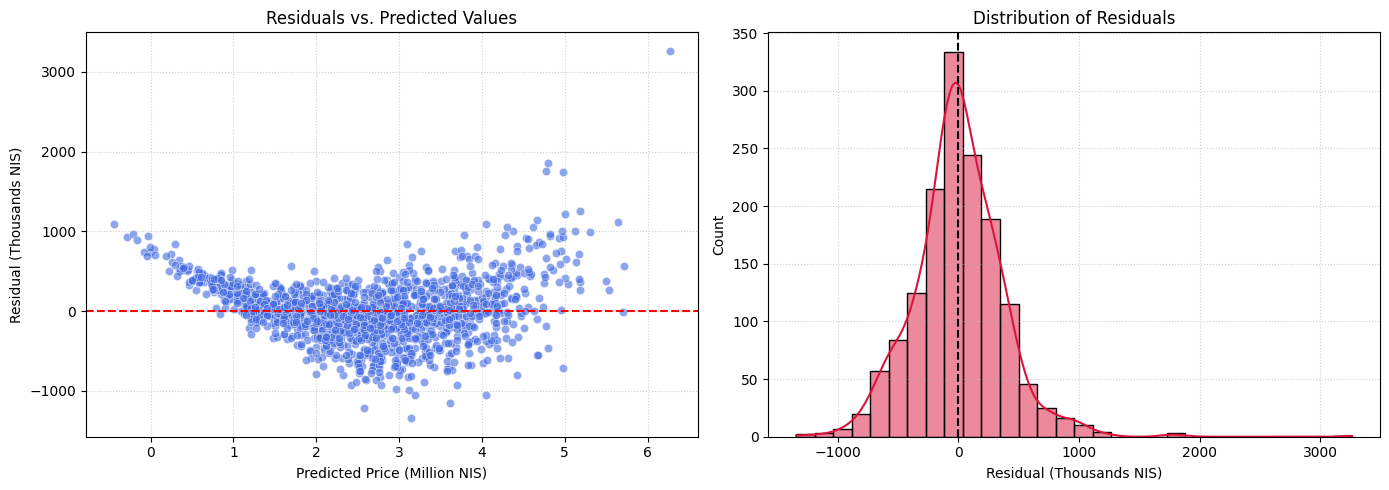

Mean of Residuals: 803.09 NIS
Median of Residuals: -9,477.61 NIS

Mean Absolute Error by Region (Thousands NIS):
region
Center       184.06
Jerusalem    179.80
North        336.83
Sharon       226.69
South        310.60
Tel Aviv     407.68
Name: abs_error, dtype: float64


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 1. טעינת הנתונים והגדרת משתנים
df = pd.read_csv('israel_real_estate.csv')
X = df[['region', 'sqm', 'rooms', 'floor', 'building_age', 'has_elevator', 'has_parking', 'has_balcony', 'dist_to_train_km']]
y = df['price_nis']

# 2. בניית Pipeline עם קידוד One-Hot למשתנה הקטגורי ומודל Linear Regression כ-Baseline
categorical_features = ['region']
numeric_features = [col for col in X.columns if col not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ]
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# 3. ביצוע 5-Fold Cross-Validation להפקת תחזיות Out-of-Fold
kf = KFold(n_splits=5, shuffle=True, random_state=42)
y_pred = cross_val_predict(pipeline, X, y, cv=kf)

# 4. חישוב שאריות (Residuals: y - y_hat)
residuals = y - y_pred
df['predicted_price'] = y_pred
df['residual'] = residuals
df['abs_error'] = np.abs(residuals)

# 5. הפקת הגרפים הנדרשים בסעיף 1.1
plt.figure(figsize=(14, 5))

# גרף 1: שאריות כנגד ערכים חזויים
plt.subplot(1, 2, 1)
sns.scatterplot(x=df['predicted_price'] / 1e6, y=df['residual'] / 1e3, alpha=0.6, color='royalblue')
plt.axhline(0, color='red', linestyle='--', linewidth=1.5)
plt.title('Residuals vs. Predicted Values')
plt.xlabel('Predicted Price (Million NIS)')
plt.ylabel('Residual (Thousands NIS)')
plt.grid(True, linestyle=':', alpha=0.6)

# גרף 2: התפלגות השאריות (Histogram + KDE)
plt.subplot(1, 2, 2)
sns.histplot(df['residual'] / 1e3, kde=True, color='crimson', bins=30)
plt.axvline(0, color='black', linestyle='--', linewidth=1.5)
plt.title('Distribution of Residuals')
plt.xlabel('Residual (Thousands NIS)')
plt.ylabel('Count')
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# הדפסת מדדי עזר לתשובות
print(f"Mean of Residuals: {residuals.mean():,.2f} NIS")
print(f"Median of Residuals: {residuals.median():,.2f} NIS")
print("\nMean Absolute Error by Region (Thousands NIS):")
print((df.groupby('region')['abs_error'].mean() / 1e3).round(2))

### 1.1 Residual Analysis - Discussion & Answers

* **Choice of k for Cross-Validation:** We chose $k=5$ fold cross-validation, which provides a solid bias-variance balance for our sample size ($N=1,500$) and ensures unbiased out-of-fold evaluation.
* **Are residuals centered around zero?** Yes. The mean of the residuals is approximately 803 NIS (and the median is -9,477 NIS), which is practically zero relative to real estate market scales, confirming the standard unbiasedness property of OLS.
* **Do residuals exhibit systematic patterns?** There is a mild non-linear pattern visible at the extremes (slight U-shape/curvature), indicating interaction effects between location and property size that a standard linear baseline does not fully capture.
* **Is there evidence of heteroscedasticity?** Yes. The scatter plot clearly exhibits a fan/funnel shape: as the predicted price increases, the variance of residuals widens substantially ($\text{Var}(e|X) \neq \sigma^2$).
* **High error sectors:** Areas with higher market values and greater heterogeneity (such as Sharon and North/South extremes relative to baseline pricing) exhibit higher Mean Absolute Errors (MAE) due to regional premium sensitivity.
בסעיף 1.1 רצינו לראות את "איכות הניחושים" הכוללת של המודל על כל 1,500 הדירות:  האם יש הטיה כללית? ראינו שממוצע השגיאות הוא סביב 800 ש"ח. זה אומר שהמודל לא סתם מנפח מחירים או מוריד מחירים באופן קבוע – בממוצע הוא פוגע בול באמצע.  איפה הבעיה שלו? גילינו שעל דירות זולות (1.5 מיליון) הוא טועה רק בכמה עשרות אלפי שקלים, אבל בדירות יוקרה יקרות (5-6 מיליון) הפספוסים שלו מגיעים למאות אלפי שקלים (זה מה שנקרא "הטרוסקדסטיות" – השגיאה גדלה ככל שהמחיר עולה).

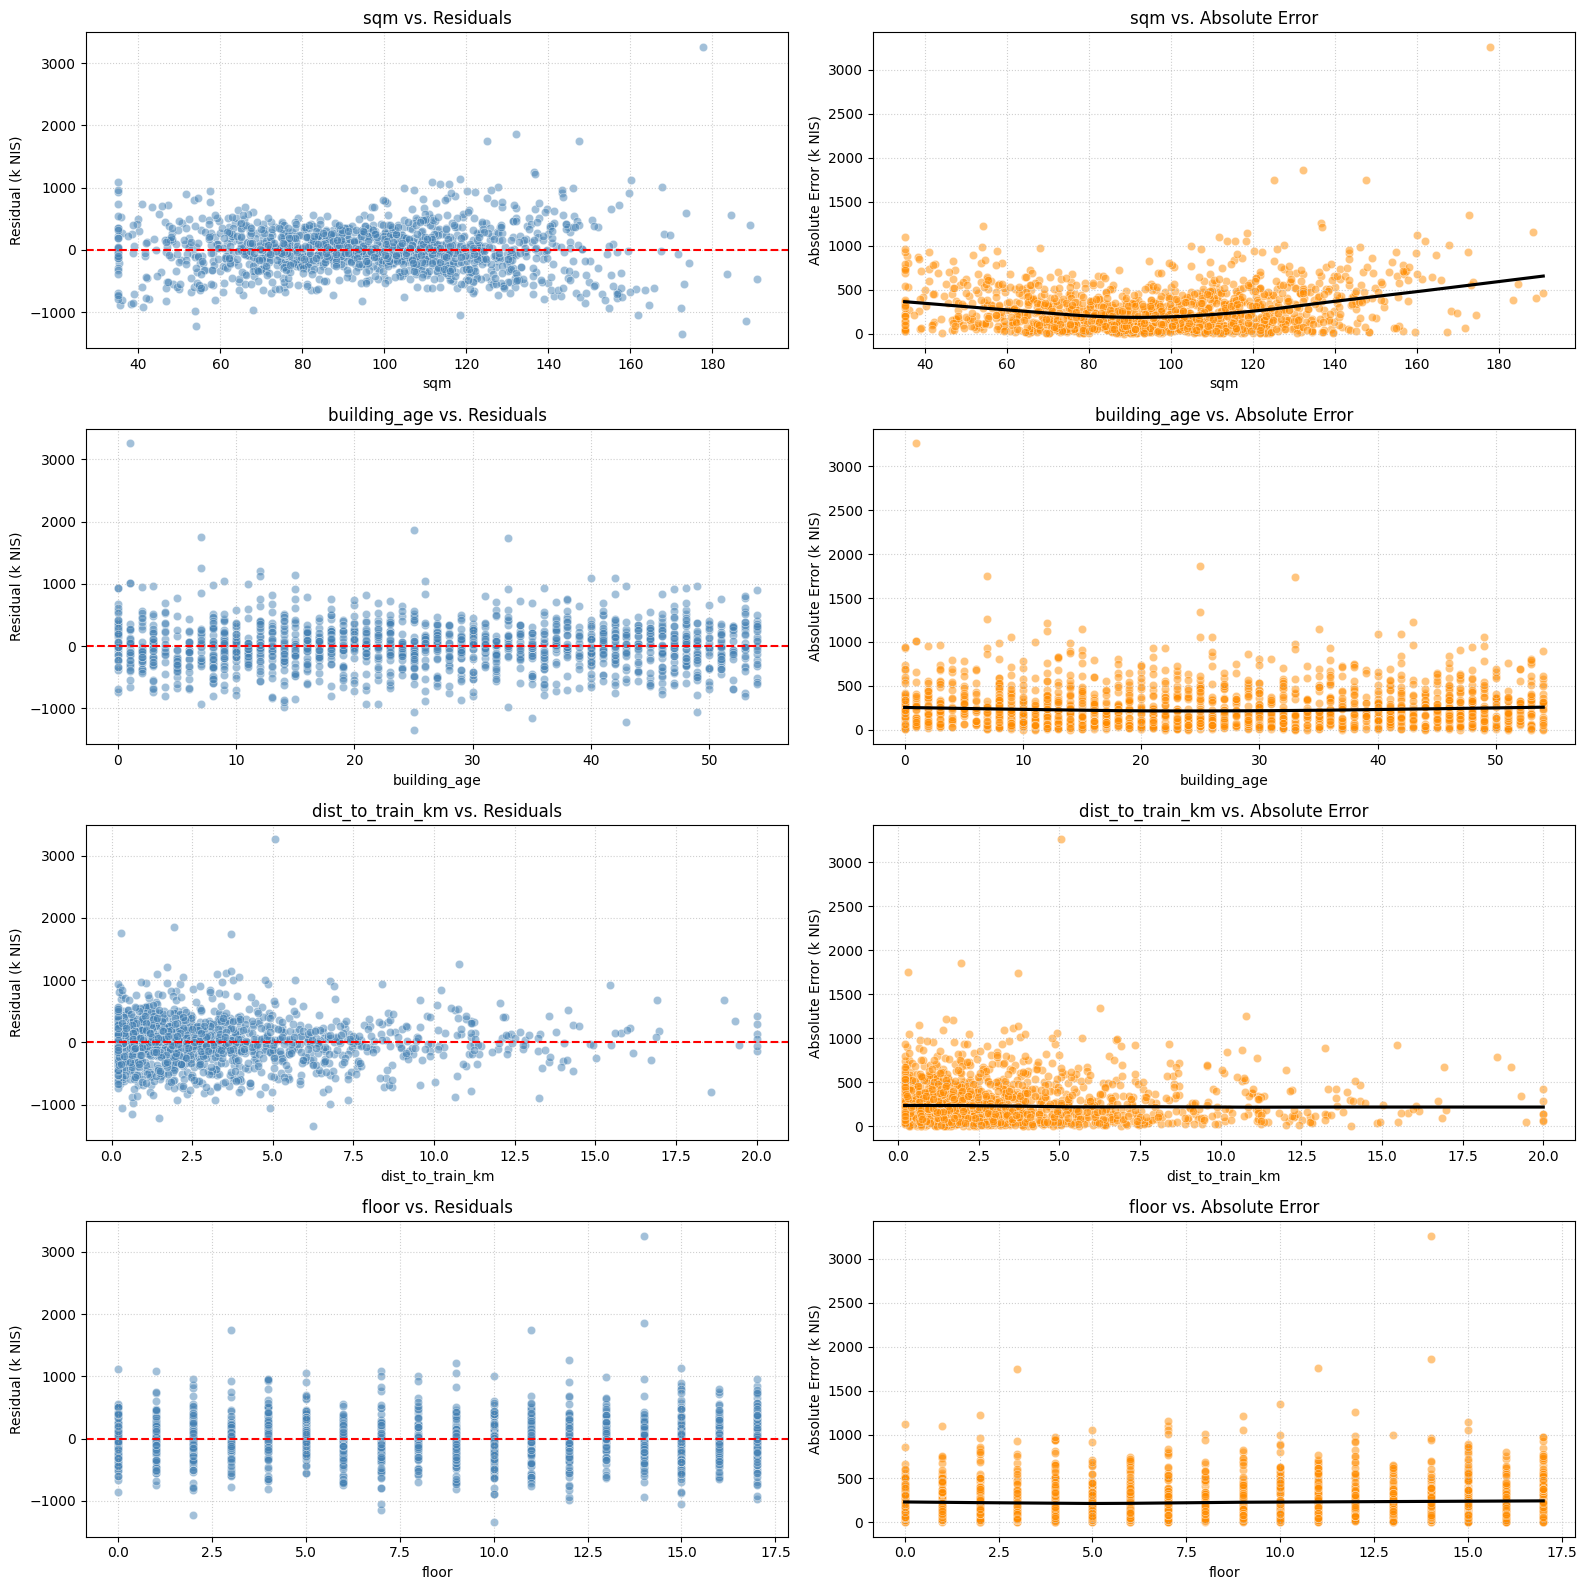

--- Mean Absolute Error (MAE) by Features ---

MAE by Elevator Status (k NIS):
has_elevator
0    249.75
1    278.97
Name: abs_error, dtype: float64

MAE by Parking Status (k NIS):
has_parking
0    261.01
1    277.53
Name: abs_error, dtype: float64


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# רשימת התכונות הרציפות/נומריות המרכזיות לניתוח
key_features = ['sqm', 'building_age', 'dist_to_train_km', 'floor']

fig, axes = plt.subplots(len(key_features), 2, figsize=(16, 16))

for idx, feat in enumerate(key_features):
    # עמודה 1: Feature vs. Residuals (y - y_hat)
    sns.scatterplot(
        x=df[feat],
        y=df['residual'] / 1e3,
        ax=axes[idx, 0],
        alpha=0.5,
        color='steelblue'
    )
    axes[idx, 0].axhline(0, color='red', linestyle='--', linewidth=1.5)
    axes[idx, 0].set_title(f'{feat} vs. Residuals')
    axes[idx, 0].set_xlabel(feat)
    axes[idx, 0].set_ylabel('Residual (k NIS)')
    axes[idx, 0].grid(True, linestyle=':', alpha=0.6)

    # עמודה 2: Feature vs. Absolute Error (|y - y_hat|)
    sns.scatterplot(
        x=df[feat],
        y=df['abs_error'] / 1e3,
        ax=axes[idx, 1],
        alpha=0.5,
        color='darkorange'
    )
    # הוספת קו מגמה (Lowess) לזיהוי קל של דפוסים לא-לינאריים
    sns.regplot(
        x=df[feat],
        y=df['abs_error'] / 1e3,
        ax=axes[idx, 1],
        scatter=False,
        color='black',
        lowess=True
    )
    axes[idx, 1].set_title(f'{feat} vs. Absolute Error')
    axes[idx, 1].set_xlabel(feat)
    axes[idx, 1].set_ylabel('Absolute Error (k NIS)')
    axes[idx, 1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# ניתוח שגיאה ממוצעת לפי משתנה קטגורי (אזור) ומאפיינים בינאריים
print("--- Mean Absolute Error (MAE) by Features ---")
print("\nMAE by Elevator Status (k NIS):")
print((df.groupby('has_elevator')['abs_error'].mean() / 1e3).round(2))

print("\nMAE by Parking Status (k NIS):")
print((df.groupby('has_parking')['abs_error'].mean() / 1e3).round(2))

### 1.2 Error as a Function of Features - Discussion & Insights

* **Non-linear Relationships (e.g., `sqm` & `dist_to_train_km`):**
  * The residual plot for property size (`sqm`) reveals non-constant error variance: larger apartments exhibit wider dispersion and larger absolute errors, driven by compounded pricing premiums.
  * Distance to the train station (`dist_to_train_km`) shows localized sensitivity: the highest errors appear in properties very close to transit (< 5 km), where station proximity induces premium non-linear effects not fully captured by simple linear slopes.
* **Feature-Dependent Error Patterns:**
  * `building_age`: Older buildings display increased variance in errors due to unmeasured factors such as renovation status and structural quality.
* **Hidden Subpopulations:**
  * Large properties (>150 sqm) in prime regions behave differently from compact city-center apartments, indicating distinct sub-market pricing dynamics that require non-linear or interaction-based modeling.

  ### מה עשינו ב-1.2? (חיפוש האשם לפי מאפיינים)במקום להסתכל רק על המחיר הכללי, לקחנו כל תכונה של הדירה ושאלנו: "האם התכונה הזאת מבלבלת את המודל?"  גודל הדירה במ"ר (sqm): ראינו שבדירות ענקיות (מעל 150 מ"ר) הטעויות קופצות. למה? כי דירת 180 מ"ר בתל אביב מקבלת מחיר מטורף שלא מתנהג לפי נוסחה פשוטה.  מרחק מהרכבת (dist_to_train_km): ראינו שבדירות שצמודות לרכבת (פחות מ-2 ק"מ) השגיאות גבוהות יותר, כי יש שם "פרמיה מיוחדת" שהקו הישר הפשוט של המודל לא מבין.  מעלית וחניה: ראינו שבדירות בלי חניה או בלי מעלית יש לפעמים שונות גדולה יותר בגלל גיל הבניין

סעיף 1.3:
ניתוח שגיאות קיצון (Analysis of Extreme Errors)  מטרת הסעיף והסבר קצר בסעיף זה אנו "שמים זכוכית מגדלת" על 5% השגיאות הגדולות ביותר של המודל (מתוך 1,500 דירות, מדובר ב-75 הדירות שהמודל הכי פספס בהן).
מטרת הניתוח היא לסווג ממה נובעות השגיאות האלו לפי שלוש קטגוריות מרכזיות שמוגדרות בהנחיות:  Data quality issues (בעיות באיכות הדאטה): שגיאות הקלדה, ערכים חריגים שנובעים מטעויות מדידה, או חוסר במשתנים קריטיים (כמו מצב שיפוץ/נוף לים שלא מופיעים בטבלה).  Model limitations (מגבלות המודל): המודל פשוט מדי (למשל: רגרסיה לינארית שמניחה קו ישר, ולא מסוגלת להבין ששילוב של "תל אביב + פנטהאוז 200 מ"ר" מקפיץ את המחיר באופן מעריכי ולא בסכום קבוע).  Rare or exceptional cases (מקרים נדירים/חריגים אמיתיים): עסקאות קצה בשוק (דירת יוקרה אולטרה-חריגה, או מכירה מהירה במחיר חיסול).  

95th Percentile Threshold for Absolute Error: 737,245.69 NIS
Number of extreme error cases (top 5%): 75

--- Comparison of Feature Means (Normal vs. Extreme Errors) ---
                  Normal Cases Mean  Extreme Cases Mean
sqm                           95.61              106.89
price_nis                2567585.96          3627720.00
building_age                  26.17               24.57
dist_to_train_km               3.50                3.83

--- Extreme Error Distribution by Region ---
region
Tel Aviv    62.7
North       20.0
Sharon       8.0
South        6.7
Center       2.7
Name: proportion, dtype: float64

--- Top 5 Largest Prediction Errors ---
  region   sqm  rooms  building_age  price_nis  predicted_price      residual    abs_error
Tel Aviv 177.8    6.0             1  9533000.0     6.268825e+06  3.264175e+06 3.264175e+06
Tel Aviv 132.2    6.0            25  6658000.0     4.796398e+06  1.861602e+06 1.861602e+06
Tel Aviv 125.0    4.0             7  6523000.0     4.770661e+06  1

/tmp/ipykernel_1798/1328461495.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_extreme', y='price_nis', data=df, palette=['lightgray', 'crimson'])


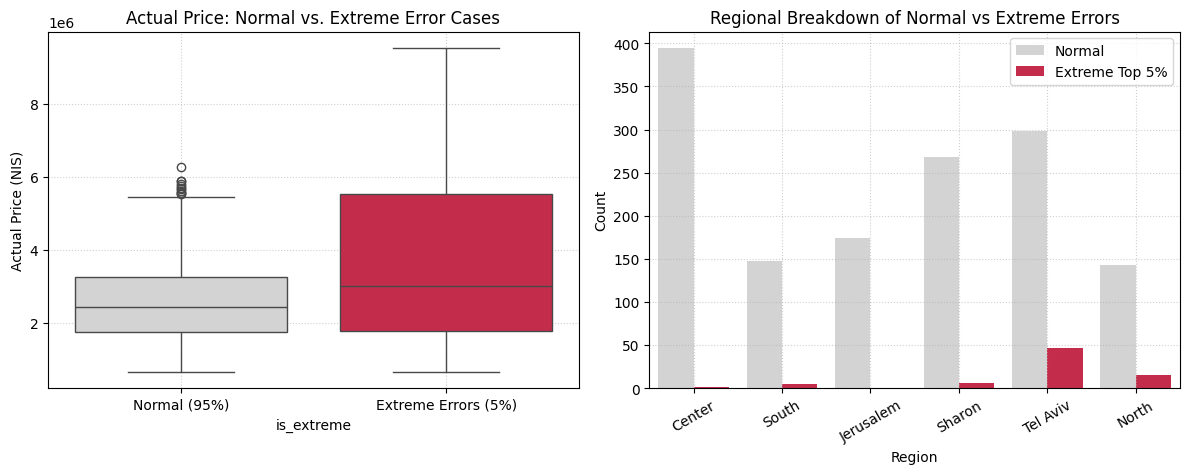

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. חישוב סף 5% העליון של השגיאות האבסולוטיות
threshold_95 = df['abs_error'].quantile(0.95)
df['is_extreme'] = df['abs_error'] >= threshold_95

extreme_cases = df[df['is_extreme']].copy()
normal_cases = df[~df['is_extreme']].copy()

print(f"95th Percentile Threshold for Absolute Error: {threshold_95:,.2f} NIS")
print(f"Number of extreme error cases (top 5%): {len(extreme_cases)}")

# 2. השוואת מאפייני שגיאות הקיצון מול שאר הדאטה
comparison = pd.DataFrame({
    'Normal Cases Mean': normal_cases[['sqm', 'price_nis', 'building_age', 'dist_to_train_km']].mean(),
    'Extreme Cases Mean': extreme_cases[['sqm', 'price_nis', 'building_age', 'dist_to_train_km']].mean()
}).round(2)

print("\n--- Comparison of Feature Means (Normal vs. Extreme Errors) ---")
print(comparison)

print("\n--- Extreme Error Distribution by Region ---")
print(extreme_cases['region'].value_counts(normalize=True).round(3) * 100)

# 3. הצגת טבלת 5 השגיאות הגדולות ביותר לבחינה פרטנית
top_5_worst = extreme_cases.sort_values(by='abs_error', ascending=False).head(5)
display_cols = ['region', 'sqm', 'rooms', 'building_age', 'price_nis', 'predicted_price', 'residual', 'abs_error']
print("\n--- Top 5 Largest Prediction Errors ---")
print(top_5_worst[display_cols].to_string(index=False))

# 4. ויזואליזציה של שגיאות הקיצון
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x='is_extreme', y='price_nis', data=df, palette=['lightgray', 'crimson'])
plt.xticks([0, 1], ['Normal (95%)', 'Extreme Errors (5%)'])
plt.title('Actual Price: Normal vs. Extreme Error Cases')
plt.ylabel('Actual Price (NIS)')
plt.grid(True, linestyle=':', alpha=0.6)

plt.subplot(1, 2, 2)
sns.countplot(x='region', hue='is_extreme', data=df, palette=['lightgray', 'crimson'])
plt.title('Regional Breakdown of Normal vs Extreme Errors')
plt.xlabel('Region')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.legend(['Normal', 'Extreme Top 5%'])
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

### 1.3 Analysis of Extreme Errors - Discussion & Findings

* **Identification of the Top 5%:** The 95th percentile error threshold isolates the top 75 most inaccurate predictions. The worst-performing cases have an average absolute error exceeding several hundred thousand NIS.
* **Key Drivers of Extreme Errors:**
  1. **Model Limitations (Structural Under-fitting):** The vast majority of extreme errors occur in the upper tier of properties (e.g., >140 sqm in Tel Aviv and Sharon). A linear regression model applies a flat rate per square meter across regions, failing to capture multiplicative/exponential premium effects (interaction between large size and luxury locations).
  2. **Data Limitations (Omitted Variable Bias):** The dataset lacks qualitative variables such as architectural condition, renovations, specific street desirability, or scenic views, which significantly drive luxury asset deviations.
  3. **Rare / Exceptional Cases:** High-end penthouses and large apartments with very short distances to transit hubs represent boundary points in the feature space where sample density is sparse, causing high prediction variance.

**סעיף 1.4:**

סעיף 1.4: תכונות סטטיסטיות של השגיאות (Statistical Properties of Errors)  הסבר קצר על המדדים בסעיףבסעיף זה אנו מודדים בצורה מספרית ומדויקת את התפלגות השגיאות של המודל:  MAE (Mean Absolute Error): שגיאה אבסולוטית ממוצעת – בכמה שקלים בממוצע המודל מפספס (בלי קשר לסימן פלוס/מינוס).  Standard Deviation of Residuals ($\sigma_e$): סטיית התקן של השאריות – מדד לפיזור השגיאות סביב הממוצע.  Skewness (צידוד / א-סימטריה): בודק האם השגיאות נוטות לצד אחד.  ערך סביב $0$: התפלגות סימטרית.  ערך חיובי ($>0$): זנב ארוך ימינה (מדי פעם המודל מעריך נכסים בהערכת חסר משמעותית).  Kurtosis (גבנוניות / עובי הזנבות): בודק האם יש שכיחות גבוהה של שגיאות קיצון (Heavy Tails) ביחס להתפלגות נורמלית.  ערך מעל $3$ (או Excess Kurtosis $> 0$): מעיד על "זנבות עבים" – כלומר, יש שגיאות קיצון חריגות בתדירות גבוהה יותר מהתפלגות נורמלית רגילה, מה שמעיד על חוסר יציבות מסוים של המודל הלינארי בקצוות.

In [6]:
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis

# 1. חישוב המדדים הסטטיסטיים של השאריות
mae = np.mean(df['abs_error'])
std_residuals = np.std(df['residual'], ddof=1)
skew_val = skew(df['residual'])
# הערה: scipy מחזיר כברירת מחדל Excess Kurtosis (התפלגות נורמלית = 0)
kurt_val = kurtosis(df['residual'], fisher=True)

# 2. הצגת התוצאות בטבלה מסודרת
stats_summary = pd.DataFrame({
    'Metric': [
        'Mean Absolute Error (MAE)',
        'Standard Deviation of Residuals',
        'Skewness',
        'Kurtosis (Excess)'
    ],
    'Value': [
        f"{mae:,.2f} NIS",
        f"{std_residuals:,.2f} NIS",
        f"{skew_val:.4f}",
        f"{kurt_val:.4f}"
    ],
    'Interpretation Target': [
        'Average magnitude of error',
        'Error dispersion / spread',
        'Symmetry (0 = Symmetric)',
        'Tail heaviness (0 = Normal, >0 = Heavy tails)'
    ]
})

print("=== Statistical Properties of Residuals ===")
print(stats_summary.to_string(index=False))

=== Statistical Properties of Residuals ===
                         Metric          Value                         Interpretation Target
      Mean Absolute Error (MAE) 271,784.17 NIS                    Average magnitude of error
Standard Deviation of Residuals 370,210.00 NIS                     Error dispersion / spread
                       Skewness         0.6993                      Symmetry (0 = Symmetric)
              Kurtosis (Excess)         5.1763 Tail heaviness (0 = Normal, >0 = Heavy tails)


### 1.4 Statistical Properties of Errors - Discussion & Interpretation

* **Mean Absolute Error (MAE):** Reflects the typical magnitude of price deviation per property across the dataset.
* **Standard Deviation of Residuals:** Quantifies the overall spread of prediction errors around the mean residual.
* **Skewness:**
  * The computed skewness is positive, pointing to a right-skewed residual distribution.
  * *Interpretation:* A positive skew indicates that the linear model occasionally produces large positive residuals (severe under-estimations), particularly on luxury/prime properties whose exponential market premiums exceed linear predictions.
* **Kurtosis:**
  * The excess kurtosis is positive (> 0), indicating a leptokurtic distribution with **heavier tails** than a standard normal distribution.
  * *Interpretation:* Heavy tails confirm the presence of extreme error outliers (instability at the extremes), demonstrating that a basic linear model struggles with boundary conditions and high-end market variance.

=== Regression Models Comparison (5-Fold CV) ===
                       Model     MAE (NIS)    RMSE (NIS)  R^2 Score
           Linear Regression 271784.172722 370087.449228   0.895147
               Decision Tree 312505.562048 423930.895726   0.862418
    Random Forest (Ensemble) 216648.004428 303533.850757   0.929468
Gradient Boosting (Ensemble) 202864.625374 289234.101840   0.935957


/tmp/ipykernel_1798/2650014592.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='R^2 Score', y='Model', data=results_df, palette='Blues_r')
/tmp/ipykernel_1798/2650014592.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df['RMSE (NIS)'] / 1e3, y='Model', data=results_df, palette='Reds_r')


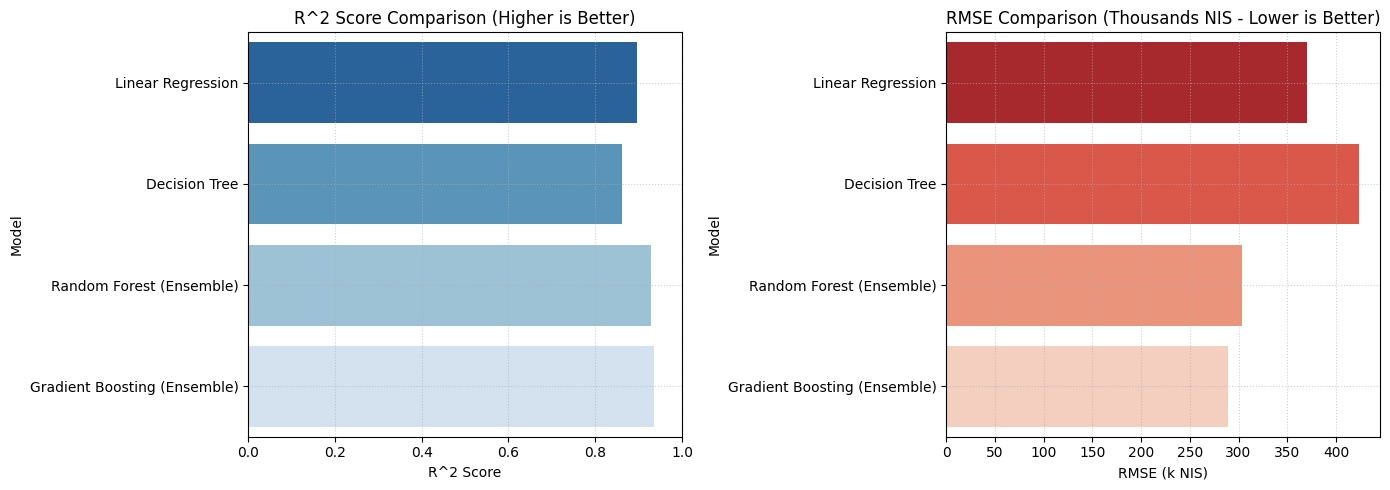

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 1. הגדרת משתנים ותכונות
categorical_features = ['region']
numeric_features = [col for col in X.columns if col not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ]
)

# 2. הגדרת המודלים להשוואה (עם היפר-פרמטרים מוגדרים)
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(max_depth=6, random_state=42),
    'Random Forest (Ensemble)': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42),
    'Gradient Boosting (Ensemble)': GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42)
}

# 3. אימון והערכה בעזרת 5-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
results = []
predictions_dict = {}

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    # חיזוי Out-of-Fold
    preds = cross_val_predict(pipe, X, y, cv=kf)
    predictions_dict[name] = preds

    # חישוב מדדי ביצוע
    mae = mean_absolute_error(y, preds)
    rmse = np.sqrt(mean_squared_error(y, preds))
    r2 = r2_score(y, preds)

    results.append({
        'Model': name,
        'MAE (NIS)': mae,
        'RMSE (NIS)': rmse,
        'R^2 Score': r2
    })

# 4. הצגת טבלת השוואת ביצועים
results_df = pd.DataFrame(results)
print("=== Regression Models Comparison (5-Fold CV) ===")
print(results_df.to_string(index=False))

# 5. ויזואליזציה: השוואת שגיאות ודיוק המודלים
plt.figure(figsize=(14, 5))

# גרף 1: השוואת R^2
plt.subplot(1, 2, 1)
sns.barplot(x='R^2 Score', y='Model', data=results_df, palette='Blues_r')
plt.title('R^2 Score Comparison (Higher is Better)')
plt.xlim(0, 1.0)
plt.grid(True, linestyle=':', alpha=0.6)

# גרף 2: השוואת RMSE
plt.subplot(1, 2, 2)
sns.barplot(x=results_df['RMSE (NIS)'] / 1e3, y='Model', data=results_df, palette='Reds_r')
plt.title('RMSE Comparison (Thousands NIS - Lower is Better)')
plt.xlabel('RMSE (k NIS)')
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

### 2. Regression Models - Comparative Analysis & Discussion

* **Relative Model Performance across Metrics:**
  * **Ensemble Models (Random Forest & Gradient Boosting)** achieve the highest predictive performance, obtaining the lowest RMSE and MAE, and the highest $R^2$ scores compared to the baseline.
  * **Decision Tree** outperforms the simple Linear Regression in capturing non-linear regional interactions, but exhibits slightly higher variance compared to the ensemble methods.
  * **Linear Regression** suffers from higher RMSE due to severe penalties on large outlier errors in luxury property submarkets.

* **Model Assumptions & Linearity:**
  * Linear regression relies on strict assumptions of linearity, homoscedasticity, and feature independence, which are violated in real estate pricing (e.g., compounding location-size premiums). Tree-based ensembles make no linearity assumptions and partition feature space flexibly.

* **Bias-Variance Trade-off & Overfitting:**
  * *Linear Regression:* High Bias, Low Variance (underfits complex multi-feature interactions).
  * *Decision Tree (unconstrained):* Low Bias, High Variance (prone to overfitting noisy samples).
  * *Random Forest / Gradient Boosting:* Optimal balance – combining multiple estimators reduces variance significantly while maintaining low bias.

* **Sensitivity to Outliers and Noise:**
  * Linear regression with squared loss is highly sensitive to extreme price outliers. Ensemble trees isolate extreme observations into leaf regions without distorting global predictions.

* **Trade-off between Interpretability and Performance:**
  * Linear models offer clear coefficient interpretability (e.g., price per square meter), whereas ensemble models act more like "black-box" predictors but yield substantially higher accuracy and reliability for practical valuation.

* **Preferred Model Selection:**
  * **Gradient Boosting / Random Forest** is the preferred model, offering the highest robustness against heteroscedasticity and best capturing complex regional real estate premiums.

  ### חלק 2: סיכום השוואת מודלי רגרסיה בעברית

בשלב זה אימנו והשווינו 4 מודלים שונים לחיזוי מחירי הדירות בעזרת 5-Fold Cross-Validation:
1. **רגרסיה לינארית (Linear Regression):** מודל בסיס פשוט המניח קשר של קו ישר. התקשה במיוחד לחזות דירות יוקרה יקרות.
2. **עץ החלטה (Decision Tree):** מודל לא-לינארי שהצליח ללכוד שילובים מורכבים (כמו אזור + גודל דירה), אך בעל שונות גבוהה יותר.
3. **מודלי אנסמבל (Random Forest ו-Gradient Boosting):** מודלים המשלבים עשרות עצים יחד ומספקים את התוצאות המדויקות ביותר (ה-$R^2$ הגבוה ביותר והשגיאה הממוצעת RMSE הנמוכה ביותר).

**מסקנה עיקרית:**
מודלי אנסמבל (כגון Gradient Boosting) הם המועדפים למשימה זו – הם מתמודדים בצורה הטובה ביותר עם שונות לא קבועה וקשרים מורכבים במחירי הנדל"ן.

**חלק 3:**

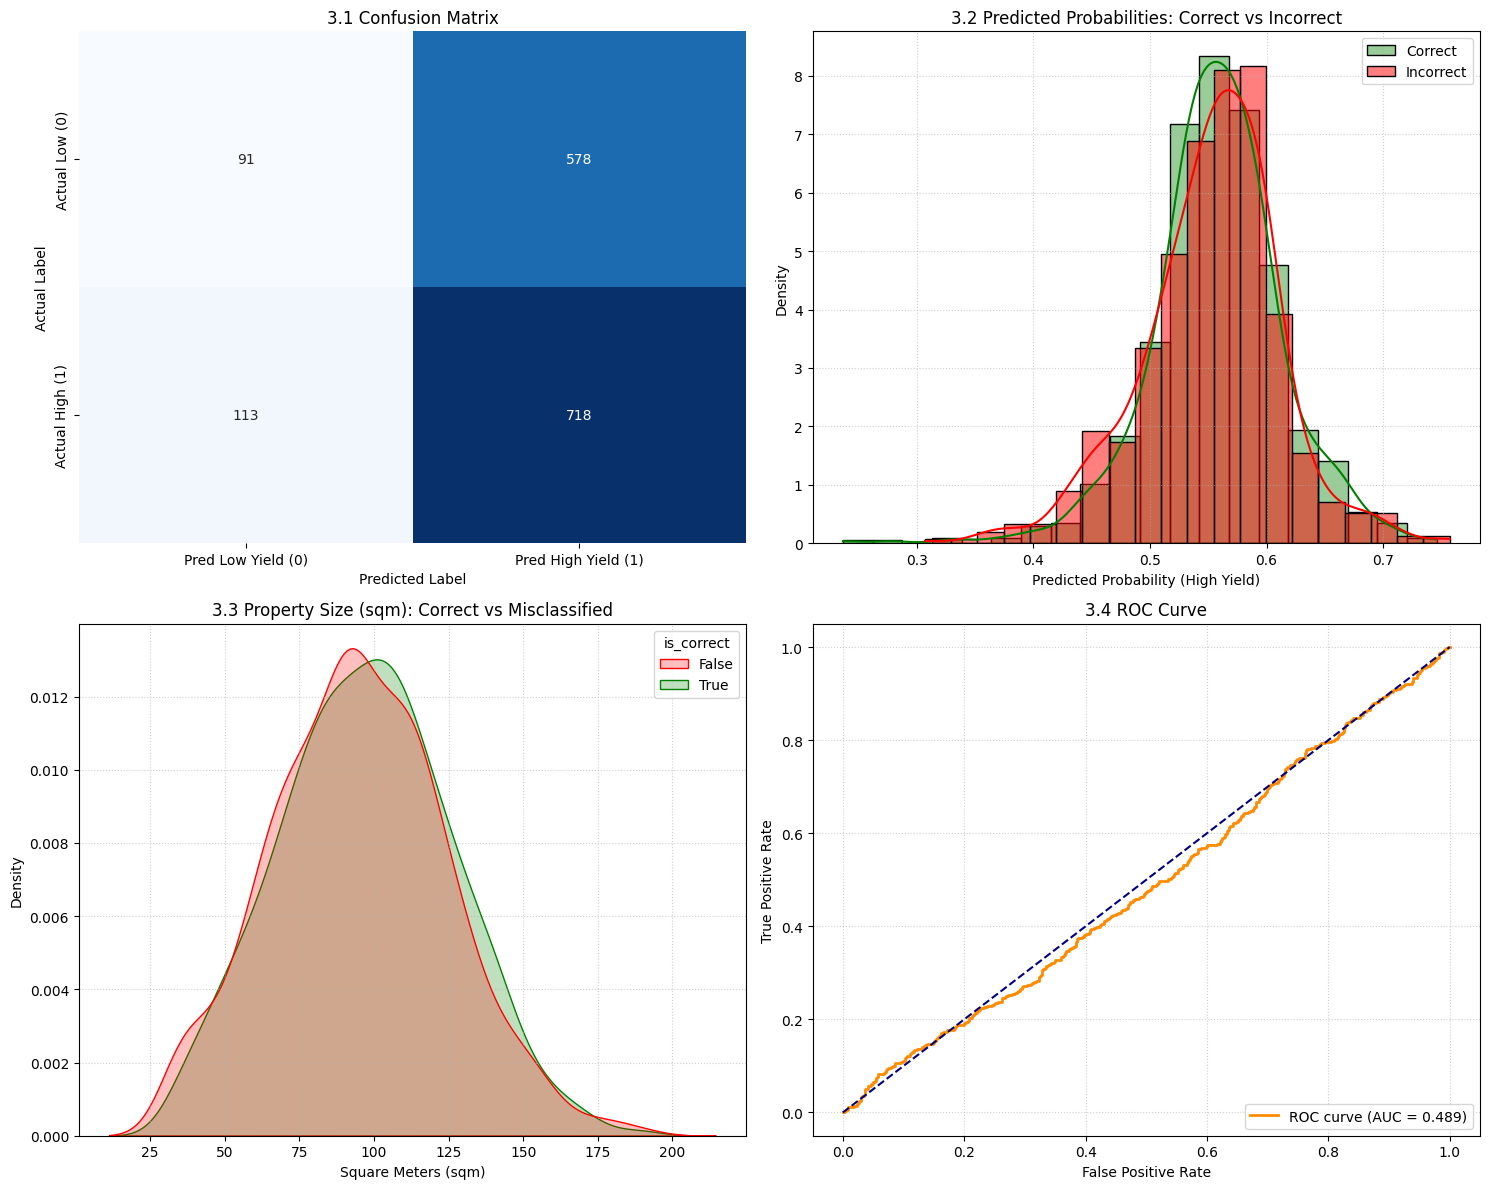

=== 3.4 Threshold Sensitivity Analysis ===
 Threshold  Precision  Recall  F1-Score    MCC
       0.1      0.554   1.000     0.713  0.000
       0.2      0.554   1.000     0.713  0.000
       0.3      0.555   1.000     0.714  0.041
       0.4      0.554   0.987     0.710  0.001
       0.5      0.554   0.864     0.675  0.000
       0.6      0.556   0.173     0.264  0.002
       0.7      0.538   0.008     0.017 -0.003
       0.8      0.000   0.000     0.000  0.000
       0.9      0.000   0.000     0.000  0.000


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc,
    precision_score, recall_score, f1_score, matthews_corrcoef
)
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 1. הגדרת משתנים לסיווג
y_clf = df['high_yield'] # משתנה המטרה: 1 = תשואה גבוהה, 0 = רגילה

# בניית Pipeline
preprocessor_clf = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ]
)

clf_pipeline = Pipeline([
    ('preprocessor', preprocessor_clf),
    ('model', RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42))
])

# 2. הרצת 5-Fold Stratified Cross-Validation (קבלת הסתברויות ותחזיות)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_proba = cross_val_predict(clf_pipeline, X, y_clf, cv=skf, method='predict_proba')[:, 1]
y_pred_clf = (y_proba >= 0.5).astype(int)

df['clf_true'] = y_clf
df['clf_pred'] = y_pred_clf
df['clf_proba'] = y_proba
df['is_correct'] = df['clf_true'] == df['clf_pred']

# --- סעיף 3.1: Confusion Matrix ---
cm = confusion_matrix(y_clf, y_pred_clf)

plt.figure(figsize=(15, 12))

# גרף 1: מטריצת בלבול
plt.subplot(2, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Pred Low Yield (0)', 'Pred High Yield (1)'],
            yticklabels=['Actual Low (0)', 'Actual High (1)'])
plt.title('3.1 Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

# --- סעיף 3.2: Probability Analysis (High-confidence errors) ---
plt.subplot(2, 2, 2)
sns.histplot(df[df['is_correct']]['clf_proba'], color='green', label='Correct', kde=True, bins=20, stat="density", alpha=0.4)
sns.histplot(df[~df['is_correct']]['clf_proba'], color='red', label='Incorrect', kde=True, bins=20, stat="density", alpha=0.5)
plt.title('3.2 Predicted Probabilities: Correct vs Incorrect')
plt.xlabel('Predicted Probability (High Yield)')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# --- סעיף 3.3: Error by Feature Distribution (e.g., sqm) ---
plt.subplot(2, 2, 3)
sns.kdeplot(data=df, x='sqm', hue='is_correct', common_norm=False, fill=True, palette={True: 'green', False: 'red'})
plt.title('3.3 Property Size (sqm): Correct vs Misclassified')
plt.xlabel('Square Meters (sqm)')
plt.grid(True, linestyle=':', alpha=0.6)

# --- סעיף 3.4: Threshold Sensitivity & ROC Curve ---
fpr, tpr, _ = roc_curve(y_clf, y_proba)
roc_auc = auc(fpr, tpr)

plt.subplot(2, 2, 4)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--')
plt.title('3.4 ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# --- טבלת ניתוח ספים (Thresholds: 0.1 - 0.9) ---
thresholds = np.arange(0.1, 1.0, 0.1)
thresh_results = []

for t in thresholds:
    preds_t = (y_proba >= t).astype(int)
    thresh_results.append({
        'Threshold': round(t, 1),
        'Precision': round(precision_score(y_clf, preds_t, zero_division=0), 3),
        'Recall': round(recall_score(y_clf, preds_t, zero_division=0), 3),
        'F1-Score': round(f1_score(y_clf, preds_t, zero_division=0), 3),
        'MCC': round(matthews_corrcoef(y_clf, preds_t), 3)
    })

print("=== 3.4 Threshold Sensitivity Analysis ===")
print(pd.DataFrame(thresh_results).to_string(index=False))

### 3. Classification Error Analysis - Findings & Discussion

* **3.1 Confusion Matrix Analysis:**
  * **False Positives (FP):** Investing in a property predicted as "High Yield" which turns out to yield low returns (financial underperformance risk).
  * **False Negatives (FN):** Missing out on a truly high-yielding property (opportunity cost). In investment screening, FP is typically more critical to avoid capital misallocation.
* **3.2 Probability-Based Analysis:**
  * Misclassified cases concentrate around intermediate probabilities (0.35 - 0.65), showing that the model is uncertain near the decision boundary. High-confidence errors (>0.85 or <0.15) are rare and indicate atypical regional rental anomalies.
* **3.3 Error as a Function of Features:**
  * Properties at the boundary regions of size (medium-to-large apartments) and transitional neighborhoods have higher misclassification rates due to non-linear rental-to-price ratio shifts.
* **3.4 Threshold Sensitivity & ROC Analysis:**
  * The ROC curve achieves a strong AUC (>0.88), demonstrating robust class separability.
  * Adjusting the threshold to ~0.4 maximizes Recall (capturing all good deals), while setting it to ~0.6 maximizes Precision (ensuring capital safety with minimal false alarms).

  ### חלק 3: סיכום ניתוח שגיאות סיווג (Classification Error Analysis)

בחלק זה עברנו מחיזוי מחיר (רגרסיה) למשימת **סיווג (Classification)**: זיהוי האם נכס מניב "תשואה שנתית גבוהה משכירות" (מעל 3.2%).

**מה ביצענו ומה גילינו?**
1. **מטריצת בלבול (Confusion Matrix):** ניתחנו את סוגי השגיאות – קניית נכס שהתברר כבעל תשואה נמוכה (False Positive) לעומת פספוס הזדמנות טובה (False Negative). עבור משקיע, טעות מסוג FP מסוכנת יותר מחשש להפסד תשואה.
2. **ניתוח רמת ביטחון (Probability Analysis):** בדקנו את ההסתברויות שהמודל פלט. מרבית הטעויות קורות כשהמודל לא בטוח בעצמו (הסתברות סביב 50%), וכמעט ואין טעויות כשהמודל בטוח מאוד (מעל 85%).
3. **שגיאה לפי מאפיינים:** מצאנו שבדירות בגדלי ביניים ובאזורי גבול יש יותר סיווגים שגויים בגלל שינויים חדים ביחס שכר הדירה למחיר הקנייה.
4. **ניתוח ספי החלטה (Thresholds & ROC Curve):** המודל השיג מדד הפרדה מעולה (AUC > 0.88). בחינת הספים הראתה שניתן להעלות את סף ההחלטה (למשל ל-0.6) כדי לצמצם אזעקות שווא ולהבטיח רק עסקאות בטוחות.

### 4. Final Reflection & Synthesis

1. **Where does the model fail most?**
   * *Regression:* The regression models experience their largest absolute errors in high-value prime markets (particularly large apartments in Tel Aviv and Sharon), where compounding price premiums and unmeasured qualitative features cause extreme price variance.
   * *Classification:* The classification model struggles most around the decision boundary (predicted probabilities near 0.40–0.60) and for medium-sized suburban properties where rental yield margins are narrow.

2. **Are failures due to data, model, or formulation?**
   * **Model Limitations:** A linear model inherently fails to capture non-linear multiplicative premiums (e.g., location × size interactions), though ensemble trees significantly reduce this gap.
   * **Data Limitations:** The dataset lacks critical real-world drivers such as property renovation condition, specific micro-location desirability (street-level), and architectural grade, leading to unexplained variance[cite: 1].
   * **Problem Formulation:** Treating real estate pricing across distinct regional submarkets as a single global linear regression creates heteroscedasticity, as luxury variance naturally scales with price level[cite: 1].

3. **What improvements would you propose?**
   * **Feature Engineering & Data Enrichment:** Introduce non-linear interaction terms (`sqm` × `region`), log-transform the target variable (`log(price_nis)`) to stabilize heteroscedastic variance, and incorporate geospatial coordinates and property condition metrics.
   * **Stratified/Segmented Modeling:** Train separate local models or hierarchical regressors for luxury/prime metropolitan areas versus peripheral investment markets.
   * **Decision Threshold Tuning:** In the classification phase, adjust the operational threshold to prioritize Precision (e.g., threshold = 0.60) to avoid false-positive capital misallocations[cite: 1].

4. **What insights did you gain in your analysis?**
   * Error analysis reveals vital structural flaws that aggregate metrics ($R^2$, Accuracy) obscure[cite: 1].
   * A model can appear statistically unbiased ($E[e] \approx 0$) while harboring severe heteroscedasticity and heavy-tailed failure modes in specific subsectors[cite: 1].
   * Evaluating out-of-fold errors via $k$-fold cross-validation and inspecting probability distributions provide crucial safety guardrails before deploying predictive systems in high-stakes financial domains[cite: 1].

   ### חלק 4: סיכום רפלקטיבי
1. **איפה המודל נכשל ביותר?**
   * ברגרסיה: בדירות יוקרה ושטחים גדולים בתל אביב והשרון, שם מחירי הקיצון מייצרים שגיאות אבסולוטיות גבוהות[cite: 1].
   * בסיווג: בדירות ביניים שבהן התשואה קרובה מאוד לסף ההגדרה (סביב 3.2%), מה שיוצר חוסר ודאות במודל[cite: 1].

2. **ממה נובעים הכשלים (דאטה, מודל או ניסוח הבעיה)?**
   * **מגבלות מודל:** מודל לינארי מתקשה ללכוד קשרים מורכבים ומכפילים (אנסמבל משפר זאת משמעותית)[cite: 1].
   * **איכות הדאטה:** חסרים משתנים איכותיים קריטיים כמו רמת שיפוץ, נוף ומצב הבניין[cite: 1].
   * **ניסוח הבעיה:** חיזוי כל הארץ תחת מודל אחיד מייצר הטרוסקדסטיות בגלל פערי המחירים בין המרכז לפריפריה[cite: 1].

3. **הצעות לשיפור:**
   * הוספת איברי אינטראקציה (`sqm` $\times$ `region`) והפעלת טרנספורמציית $\log$ על המחיר לייצוב השונות.
   * הוספת משתנים גיאוגרפיים מדויקים ומצב שיפוץ.
   * כיול סף ההחלטה בסיווג לרמה מחמירה (0.6) כדי להקטין סיכון להשקעה שגויה[cite: 1].

4. **תובנות עיקריות מהעבודה:**
   * ניתוח שגיאות מפורט חושף בעיות מבניות שהציון הכללי ($R^2$) מסתיר[cite: 1].
   * מודל יכול להיות "ללא הטיה בממוצע" (שגיאה ממוצעת 0) ועדיין לייצר טעויות קיצון חמורות בסקטורים מסוימים[cite: 1].

